# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [93]:
import pandas as pd
import numpy as np
from datetime import datetime

In [94]:
print("Hello World!")

Hello World!


### Web scraping para obtener los datos del valor de la tasa de cambio de eltoque.com durante los ultimos 2 años.



In [95]:
import requests
import json

urls = [
    'https://api.cubanomic.com/api/v1/x-rates-by-date-range-history?trmi=true&cur=USD&token=CUBANOMIC_TOKEN_REDACTED&period=730D',
    'https://api.cubanomic.com/api/v1/x-rates-by-date-range-history?trmi=true&cur=ECU&token=CUBANOMIC_TOKEN_REDACTED&period=730D',
]

# Obtener todos los datos
all_data = []
for url in urls:
    response = requests.get(url)
    data = response.json()
    all_data.append(data)
    print(f"Datos de {url.split('cur=')[1].split('&')[0]}: {len(data)} registros")

# Guardar en archivo
with open('./data/tasas_de_cambio.json', 'w', encoding='utf-8') as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

print("Datos guardados en 'tasas_de_cambio.json'")

Datos de USD: 722 registros
Datos de ECU: 726 registros
Datos guardados en 'tasas_de_cambio.json'


In [96]:
# Cargar datos
with open('data/tasas_de_cambio.json', 'r') as f:
    data_with_list = json.load(f)

### Separar y limpiar

In [97]:
# Procesar USD
data_usd = data_with_list[0]
unique_usd = {item['_id']: item for item in data_usd}
df_usd = pd.json_normalize(list(unique_usd.values()))
df_usd['fecha'] = pd.to_datetime(df_usd['_id'])
df_usd.set_index('fecha', inplace=True)
df_usd = df_usd.sort_index()

# Procesar ECU
data_ecu = data_with_list[1]
unique_ecu = {item['_id']: item for item in data_ecu}
df_ecu = pd.json_normalize(list(unique_ecu.values()))
df_ecu['fecha'] = pd.to_datetime(df_ecu['_id'])
df_ecu.set_index('fecha', inplace=True)
df_ecu = df_ecu.sort_index()

# Ahora ya tienes df_usd y df_ecu separados desde el inicio
df_usd = df_usd.resample('D').ffill()
df_ecu = df_ecu.resample('D').ffill()

### Feature ingeneering

In [98]:
# 6. Crear variables objetivo
df_usd['target'] = df_usd['avg'].shift(-1)  # Precio de mañana
df_ecu['target'] = df_ecu['avg'].shift(-1)

# 7. Crear features temporales (AHORA SÍ FUNCIONA)
# df_usd.index ahora es DatetimeIndex simple después del resample
df_usd['day_of_week'] = df_usd.index.dayofweek
df_usd['month'] = df_usd.index.month
df_usd['day'] = df_usd.index.day
df_usd['lag_1'] = df_usd['avg'].shift(1)
df_usd['lag_7'] = df_usd['avg'].shift(7)
df_usd['rolling_mean_7'] = df_usd['avg'].rolling(7).mean()

df_ecu['day_of_week'] = df_ecu.index.dayofweek
df_ecu['month'] = df_ecu.index.month
df_ecu['day'] = df_ecu.index.day
df_ecu['lag_1'] = df_ecu['avg'].shift(1)
df_ecu['lag_7'] = df_ecu['avg'].shift(7)
df_ecu['rolling_mean_7'] = df_ecu['avg'].rolling(7).mean()

# 8. Eliminar NaNs
df_usd.dropna(inplace=True)
df_ecu.dropna(inplace=True)

# Verificar estructura
print("USD DataFrame shape:", df_usd.shape)
print("ECU DataFrame shape:", df_ecu.shape)
print("\nUSD columns:", df_usd.columns.tolist())
print("\nPrimeras filas USD:")
print(df_usd[['avg', 'target', 'day_of_week', 'lag_1']].head())

USD DataFrame shape: (722, 20)
ECU DataFrame shape: (722, 20)

USD columns: ['_id', 'avg', 'count_values', 'cur', 'max', 'median', 'min', 'offer', 'trmi', 'first.date', 'first.value', 'last.date', 'last.value', 'target', 'day_of_week', 'month', 'day', 'lag_1', 'lag_7', 'rolling_mean_7']

Primeras filas USD:
               avg  target  day_of_week   lag_1
fecha                                          
2024-01-17  274.65  275.12            2  274.16
2024-01-18  275.12  276.26            3  274.65
2024-01-19  276.26  277.04            4  275.12
2024-01-20  277.04  277.86            5  276.26
2024-01-21  277.86  278.74            6  277.04


### Split de Datos

In [107]:
# 9. Seleccionar features y target
features = ['avg', 'median', 'min', 'max', 'day_of_week', 'month',
            'lag_1', 'lag_7', 'rolling_mean_7']

X_usd = df_usd[features]
y_usd = df_usd['target']

X_ecu = df_ecu[features]
y_ecu = df_ecu['target']

# Split temporal - Últimos 7 días para test
split_date = df_usd.index[-30]  # Últimos 7 días para test

X_train_usd = X_usd[X_usd.index < split_date]
X_test_usd = X_usd[X_usd.index >= split_date]
y_train_usd = y_usd[y_usd.index < split_date]
y_test_usd = y_usd[y_usd.index >= split_date]

X_train_ecu = X_ecu[X_ecu.index < split_date]
X_test_ecu = X_ecu[X_ecu.index >= split_date]
y_train_ecu = y_ecu[y_ecu.index < split_date]
y_test_ecu = y_ecu[y_ecu.index >= split_date]

print(f"Train USD: {X_train_usd.shape}, Test USD: {X_test_usd.shape}")
print(f"Train ECU: {X_train_ecu.shape}, Test ECU: {X_test_ecu.shape}")
print(f"\nRango de Test:")
print(f"  Desde: {X_test_usd.index.min()}")
print(f"  Hasta: {X_test_usd.index.max()}")
print(f"  Días de test: {len(X_test_usd)}")

Train USD: (692, 9), Test USD: (30, 9)
Train ECU: (692, 9), Test ECU: (30, 9)

Rango de Test:
  Desde: 2025-12-09 00:00:00
  Hasta: 2026-01-07 00:00:00
  Días de test: 30


### Entrenamiento del modelo
Ultimos 30 dias para test

In [110]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error


model_usd = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_usd.fit(X_train_usd, y_train_usd)

model_ecu = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_ecu.fit(X_train_ecu, y_train_ecu)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### Predicciones

In [111]:
y_pred_usd = model_usd.predict(X_test_usd)
y_pred_ecu = model_ecu.predict(X_test_ecu)

# 14. Métricas de evaluación
mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

mae_ecu = mean_absolute_error(y_test_ecu, y_pred_ecu)
rmse_ecu = np.sqrt(mean_squared_error(y_test_ecu, y_pred_ecu))

print("=== Resultados USD ===")
print(f"MAE: {mae_usd:.4f}")
print(f"RMSE: {rmse_usd:.4f}")

print("\n=== Resultados ECU ===")
print(f"MAE: {mae_ecu:.4f}")
print(f"RMSE: {rmse_ecu:.4f}")

=== Resultados USD ===
MAE: 1.9543
RMSE: 2.5253

=== Resultados ECU ===
MAE: 2.3912
RMSE: 2.9029


### Visualizacion

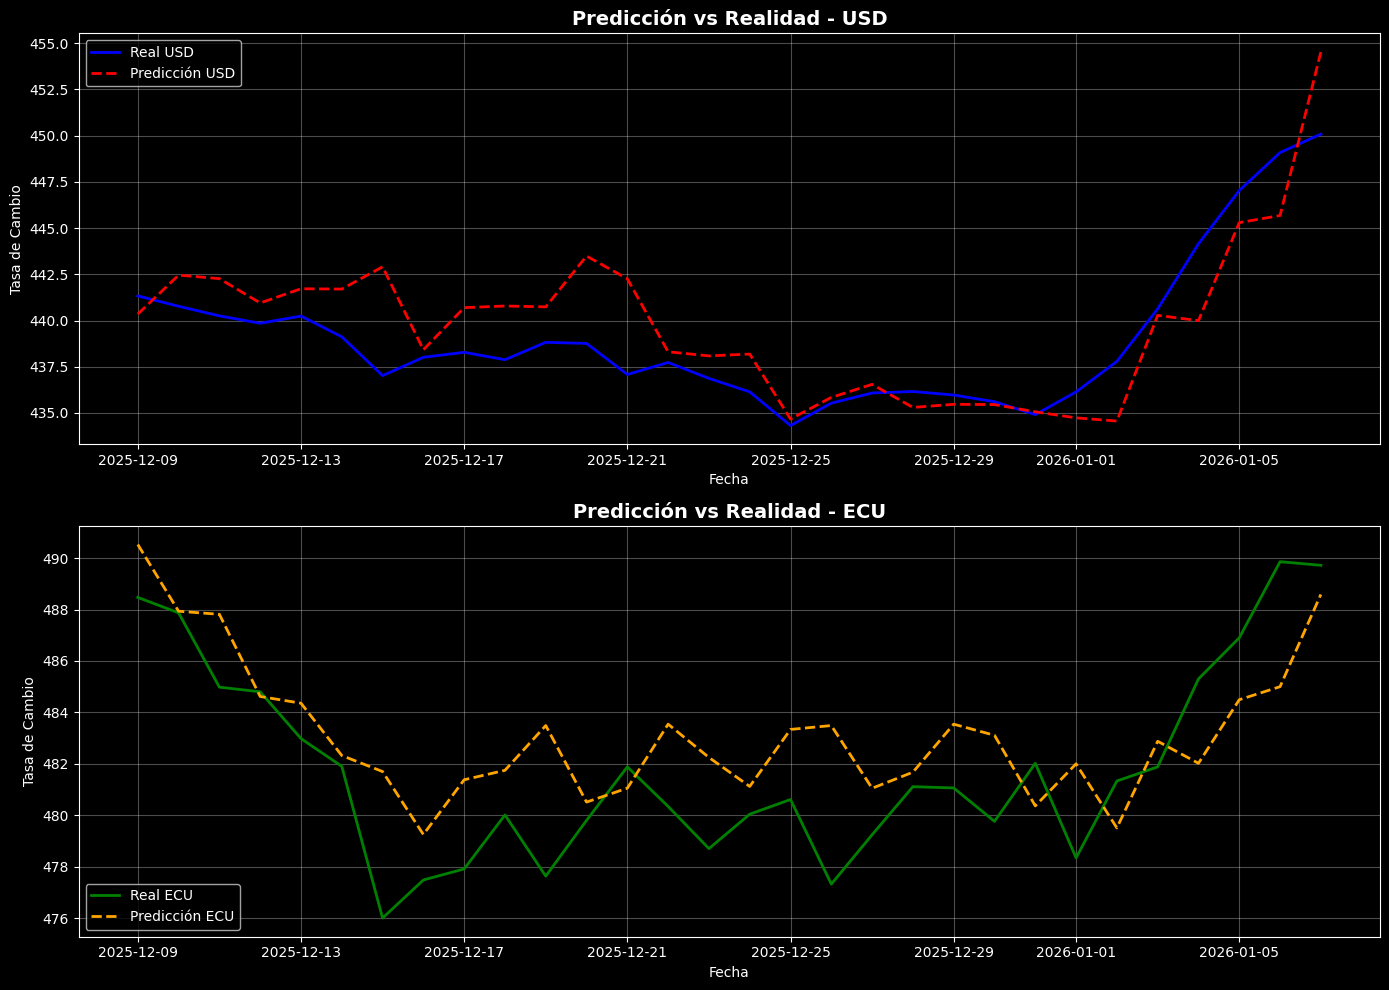

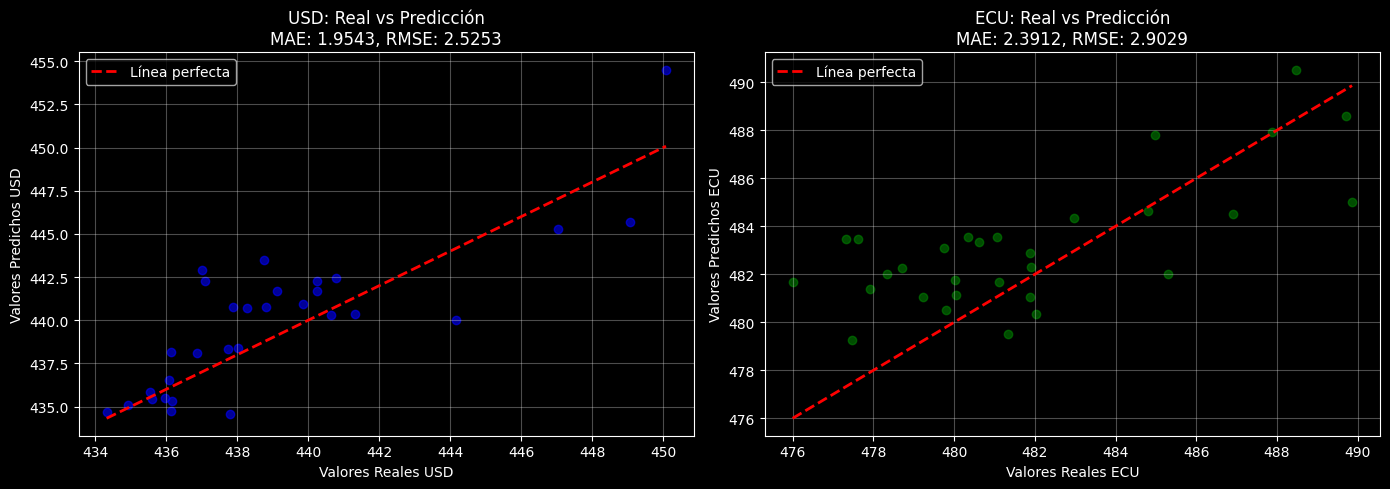

In [112]:
import matplotlib.pyplot as plt

# Crear figura con dos subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot USD
axes[0].plot(y_test_usd.index, y_test_usd.values, label='Real USD', color='blue', linewidth=2)
axes[0].plot(y_test_usd.index, y_pred_usd, label='Predicción USD', color='red', linewidth=2, linestyle='--')
axes[0].set_title('Predicción vs Realidad - USD', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Tasa de Cambio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot ECU
axes[1].plot(y_test_ecu.index, y_test_ecu.values, label='Real ECU', color='green', linewidth=2)
axes[1].plot(y_test_ecu.index, y_pred_ecu, label='Predicción ECU', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Predicción vs Realidad - ECU', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Tasa de Cambio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de dispersión para evaluar precisión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter USD
axes[0].scatter(y_test_usd, y_pred_usd, alpha=0.6, color='blue')
axes[0].plot([y_test_usd.min(), y_test_usd.max()],
             [y_test_usd.min(), y_test_usd.max()],
             'r--', lw=2, label='Línea perfecta')
axes[0].set_xlabel('Valores Reales USD')
axes[0].set_ylabel('Valores Predichos USD')
axes[0].set_title(f'USD: Real vs Predicción\nMAE: {mae_usd:.4f}, RMSE: {rmse_usd:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter ECU
axes[1].scatter(y_test_ecu, y_pred_ecu, alpha=0.6, color='green')
axes[1].plot([y_test_ecu.min(), y_test_ecu.max()],
             [y_test_ecu.min(), y_test_ecu.max()],
             'r--', lw=2, label='Línea perfecta')
axes[1].set_xlabel('Valores Reales ECU')
axes[1].set_ylabel('Valores Predichos ECU')
axes[1].set_title(f'ECU: Real vs Predicción\nMAE: {mae_ecu:.4f}, RMSE: {rmse_ecu:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analisis de las peores predicciones

In [113]:
# Calcular diferencias absolutas
diff_usd = pd.DataFrame({
    'fecha': y_test_usd.index,
    'real': y_test_usd.values,
    'prediccion': y_pred_usd,
    'diferencia_abs': np.abs(y_test_usd.values - y_pred_usd),
    'diferencia': y_test_usd.values - y_pred_usd
})

diff_ecu = pd.DataFrame({
    'fecha': y_test_ecu.index,
    'real': y_test_ecu.values,
    'prediccion': y_pred_ecu,
    'diferencia_abs': np.abs(y_test_ecu.values - y_pred_ecu),
    'diferencia': y_test_ecu.values - y_pred_ecu
})

# Encontrar días con mayor diferencia
print("=== USD - Día con mayor error ===")
max_error_usd = diff_usd.loc[diff_usd['diferencia_abs'].idxmax()]
print(f"Fecha: {max_error_usd['fecha']}")
print(f"Valor Real: {max_error_usd['real']:.2f}")
print(f"Predicción: {max_error_usd['prediccion']:.2f}")
print(f"Error Absoluto: {max_error_usd['diferencia_abs']:.2f}")
print(f"Error: {max_error_usd['diferencia']:.2f}")

print("\n=== ECU - Día con mayor error ===")
max_error_ecu = diff_ecu.loc[diff_ecu['diferencia_abs'].idxmax()]
print(f"Fecha: {max_error_ecu['fecha']}")
print(f"Valor Real: {max_error_ecu['real']:.2f}")
print(f"Predicción: {max_error_ecu['prediccion']:.2f}")
print(f"Error Absoluto: {max_error_ecu['diferencia_abs']:.2f}")
print(f"Error: {max_error_ecu['diferencia']:.2f}")

# Top 5 días con mayor error
print("\n=== Top 5 errores USD ===")
print(diff_usd.nlargest(5, 'diferencia_abs')[['fecha', 'real', 'prediccion', 'diferencia_abs']])

print("\n=== Top 5 errores ECU ===")
print(diff_ecu.nlargest(5, 'diferencia_abs')[['fecha', 'real', 'prediccion', 'diferencia_abs']])

=== USD - Día con mayor error ===
Fecha: 2025-12-15 00:00:00
Valor Real: 437.02
Predicción: 442.90
Error Absoluto: 5.88
Error: -5.88

=== ECU - Día con mayor error ===
Fecha: 2025-12-26 00:00:00
Valor Real: 477.32
Predicción: 483.49
Error Absoluto: 6.17
Error: -6.17

=== Top 5 errores USD ===
        fecha    real  prediccion  diferencia_abs
6  2025-12-15  437.02  442.904907        5.884907
12 2025-12-21  437.08  442.254425        5.174425
11 2025-12-20  438.76  443.486298        4.726298
29 2026-01-07  450.08  454.518524        4.438524
26 2026-01-04  444.15  439.993286        4.156714

=== Top 5 errores ECU ===
        fecha    real  prediccion  diferencia_abs
17 2025-12-26  477.32  483.486908        6.166908
10 2025-12-19  477.63  483.486908        5.856908
6  2025-12-15  476.00  481.697113        5.697113
28 2026-01-06  489.86  484.998627        4.861373
23 2026-01-01  478.34  481.997528        3.657528


### Predicciones para los proximos 7 dias usando todos los datos para entrenar

Datos completos USD: (722, 9)
Datos completos ECU: (722, 9)
Último día de datos: 2026-01-07 00:00:00

✓ Modelos re-entrenados con datos completos


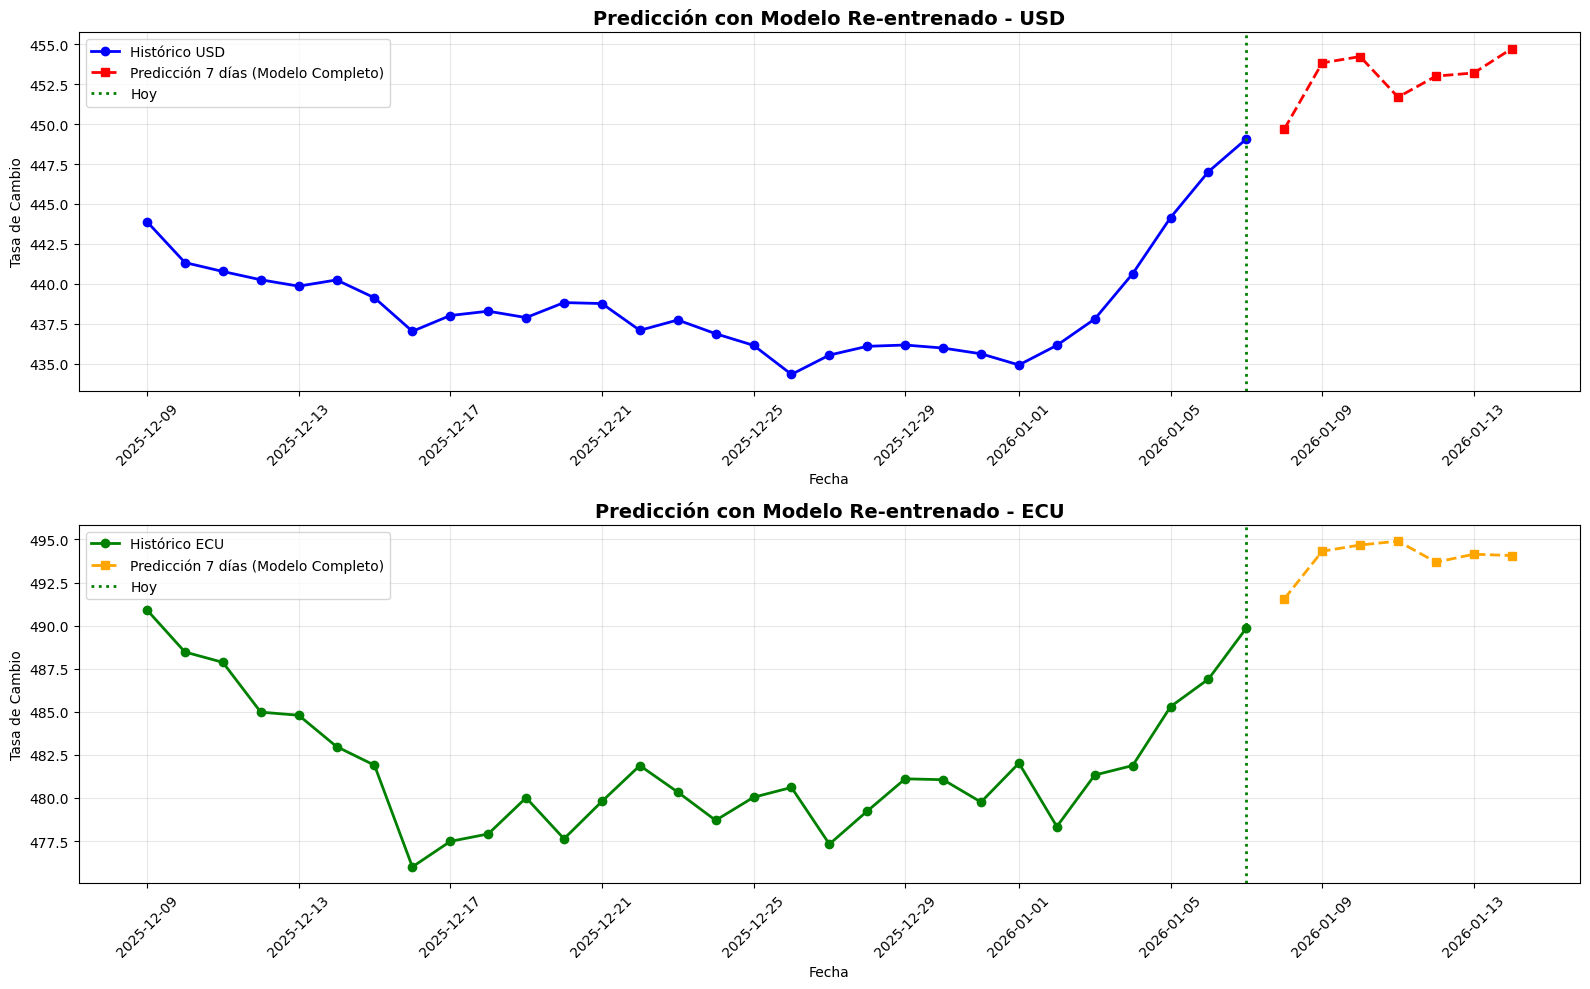

=== Predicciones USD - Próximos 7 Días (Modelo Completo) ===
Valor actual: 449.08

Predicciones:
2026-01-08: 449.70 (Cambio: +0.62, +0.14%)
2026-01-09: 453.85 (Cambio: +4.77, +1.06%)
2026-01-10: 454.24 (Cambio: +5.16, +1.15%)
2026-01-11: 451.70 (Cambio: +2.62, +0.58%)
2026-01-12: 453.02 (Cambio: +3.94, +0.88%)
2026-01-13: 453.21 (Cambio: +4.13, +0.92%)
2026-01-14: 454.74 (Cambio: +5.66, +1.26%)

=== Predicciones ECU - Próximos 7 Días (Modelo Completo) ===
Valor actual: 489.86

Predicciones:
2026-01-08: 491.55 (Cambio: +1.69, +0.35%)
2026-01-09: 494.32 (Cambio: +4.46, +0.91%)
2026-01-10: 494.68 (Cambio: +4.82, +0.98%)
2026-01-11: 494.91 (Cambio: +5.05, +1.03%)
2026-01-12: 493.68 (Cambio: +3.82, +0.78%)
2026-01-13: 494.15 (Cambio: +4.29, +0.87%)
2026-01-14: 494.07 (Cambio: +4.21, +0.86%)


In [105]:
# Usar TODOS los datos históricos para entrenar
X_train_full_usd = X_usd
y_train_full_usd = y_usd

X_train_full_ecu = X_ecu
y_train_full_ecu = y_ecu

print(f"Datos completos USD: {X_train_full_usd.shape}")
print(f"Datos completos ECU: {X_train_full_ecu.shape}")
print(f"Último día de datos: {X_train_full_usd.index[-1]}")

# Re-entrenar modelos con todos los datos
model_usd_full = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model_usd_full.fit(X_train_full_usd, y_train_full_usd)

model_ecu_full = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model_ecu_full.fit(X_train_full_ecu, y_train_full_ecu)

print("\n✓ Modelos re-entrenados con datos completos")

# Ahora predecir con los nuevos modelos
future_usd_full = predict_next_days(model_usd_full, df_usd, days=7)
future_ecu_full = predict_next_days(model_ecu_full, df_ecu, days=7)

# Visualizar comparación
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# USD
axes[0].plot(df_usd.index[-30:], df_usd['avg'].tail(30),
             label='Histórico USD', color='blue', linewidth=2, marker='o')
axes[0].plot(future_usd_full['fecha'], future_usd_full['prediccion'],
             label='Predicción 7 días (Modelo Completo)', color='red',
             linewidth=2, linestyle='--', marker='s')
axes[0].axvline(x=df_usd.index[-1], color='green', linestyle=':',
                linewidth=2, label='Hoy')
axes[0].set_title('Predicción con Modelo Re-entrenado - USD',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Tasa de Cambio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# ECU
axes[1].plot(df_ecu.index[-30:], df_ecu['avg'].tail(30),
             label='Histórico ECU', color='green', linewidth=2, marker='o')
axes[1].plot(future_ecu_full['fecha'], future_ecu_full['prediccion'],
             label='Predicción 7 días (Modelo Completo)', color='orange',
             linewidth=2, linestyle='--', marker='s')
axes[1].axvline(x=df_ecu.index[-1], color='green', linestyle=':',
                linewidth=2, label='Hoy')
axes[1].set_title('Predicción con Modelo Re-entrenado - ECU',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Tasa de Cambio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Mostrar predicciones
print("=== Predicciones USD - Próximos 7 Días (Modelo Completo) ===")
print(f"Valor actual: {df_usd['avg'].iloc[-1]:.2f}")
print("\nPredicciones:")
for idx, row in future_usd_full.iterrows():
    cambio = row['prediccion'] - df_usd['avg'].iloc[-1]
    cambio_pct = (cambio / df_usd['avg'].iloc[-1]) * 100
    print(f"{row['fecha'].strftime('%Y-%m-%d')}: {row['prediccion']:.2f} "
          f"(Cambio: {cambio:+.2f}, {cambio_pct:+.2f}%)")

print("\n=== Predicciones ECU - Próximos 7 Días (Modelo Completo) ===")
print(f"Valor actual: {df_ecu['avg'].iloc[-1]:.2f}")
print("\nPredicciones:")
for idx, row in future_ecu_full.iterrows():
    cambio = row['prediccion'] - df_ecu['avg'].iloc[-1]
    cambio_pct = (cambio / df_ecu['avg'].iloc[-1]) * 100
    print(f"{row['fecha'].strftime('%Y-%m-%d')}: {row['prediccion']:.2f} "
          f"(Cambio: {cambio:+.2f}, {cambio_pct:+.2f}%)")